# Лабораторная работа № 2. Метод ломаных

Для примера взята функция Растригина
$f(x)=x^2-10\cos(2\pi x)+10$ на отрезке $[-5.12;5.12]$.
На этом отрезке есть несколько локальных минимумов. Точность $\varepsilon=0.01$.


## Константа Липшица

$f'(x)=2x+20\pi\sin(2\pi x)$. На выбранном отрезке $|x|\le5.12$
и $|\sin(2\pi x)|\le1$, поэтому
$|f'(x)|\le10.24+20\pi\approx73.07185$.
Беру $L=10.24+20\pi$.


## Формулы метода

Для соседних точек $x_i<x_{i+1}$:

$z_i=\dfrac{x_i+x_{i+1}}{2}+\dfrac{f(x_i)-f(x_{i+1})}{2L}$,
$R_i=\dfrac{f(x_i)+f(x_{i+1})-L(x_{i+1}-x_i)}{2}$.

Считаем функцию в точке с наименьшим $R_i$.
Останов, когда $U-\min R_i\le\varepsilon$,
где $U$ - наименьшее из уже посчитанных значений функции.


In [1]:
from math import *
import time
import matplotlib.pyplot as plt

expression = "x**2 - 10*cos(2*pi*x) + 10"
a, b, eps = -5.12, 5.12, 0.01
L = 10.24 + 20*pi

def f(x):
    return eval(expression)


In [2]:
start = time.perf_counter()
points = [(a, f(a)), (b, f(b))]
steps = []

while True:
    min_R = float("inf")
    for i in range(len(points) - 1):
        x1, y1 = points[i]
        x2, y2 = points[i + 1]
        z = (x1 + x2)/2 + (y1 - y2)/(2*L)
        R = (y1 + y2 - L*(x2 - x1))/2
        if R < min_R:
            min_R, pos, new_x = R, i, z

    best_x, best_y = min(points, key=lambda point: point[1])
    if best_y - min_R <= eps:
        break

    new_y = f(new_x)
    steps.append((len(steps) + 1, points[pos][0], points[pos + 1][0],
                  new_x, min_R, new_y))
    points.insert(pos + 1, (new_x, new_y))

elapsed = time.perf_counter() - start


In [3]:
print(f"x* = {best_x:.9f}")
print(f"f(x*) = {best_y:.9f}")
print(f"Итераций: {len(steps)}")
print(f"Время: {elapsed:.5f} с")
print(f"U - min(R): {best_y - min_R:.9f} <= {eps}")
print("\nПервые шаги: шаг, интервал, новая точка, R, f(новая точка)")
for k, left, right, z, R, value in steps[:3]:
    print(f"{k}: [{left:.3f}; {right:.3f}], {z:.6f}, {R:.6f}, {value:.6f}")


x* = 0.000000000
f(x*) = 0.000000000
Итераций: 151
Время: 0.02836 с
U - min(R): 0.009311510 <= 0.01

Первые шаги: шаг, интервал, новая точка, R, f(новая точка)
1: [-5.120; 5.120], 0.000000, -345.203174, 0.000000
2: [-5.120; 0.000], -2.362080, -172.601587, 22.053831
3: [0.000; 5.120], 2.362080, -172.601587, 22.053831


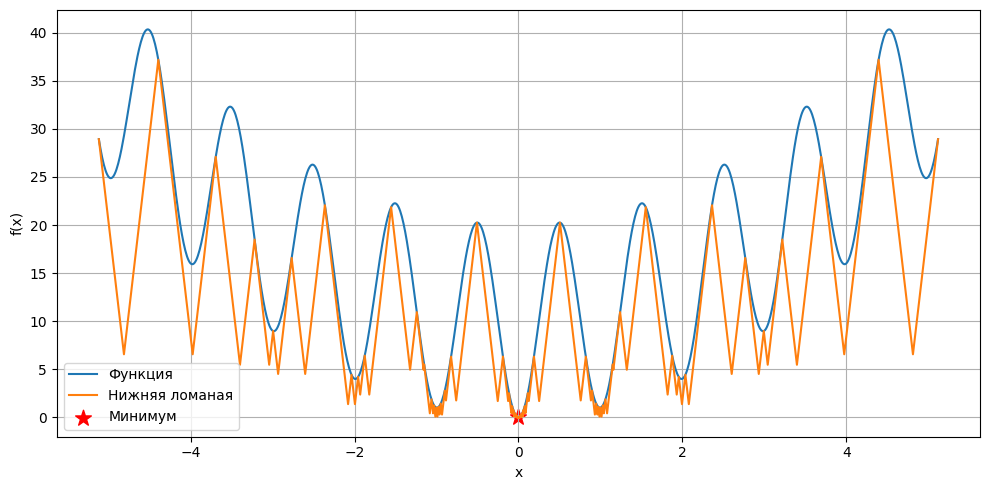

In [4]:
x_plot = [a + (b-a)*j/1000 for j in range(1001)]
y_plot = [f(x) for x in x_plot]
line_x, line_y = [], []
for i in range(len(points) - 1):
    x1, y1 = points[i]
    x2, y2 = points[i + 1]
    z = (x1 + x2)/2 + (y1 - y2)/(2*L)
    R = (y1 + y2 - L*(x2 - x1))/2
    line_x.extend([x1, z, x2])
    line_y.extend([y1, R, y2])

plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_plot, label="Функция")
plt.plot(line_x, line_y, label="Нижняя ломаная")
plt.scatter(best_x, best_y, color="red", marker="*", s=140, label="Минимум")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("grafik_metoda.png", dpi=160)
plt.show()
